In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [28]:
df_train = pd.read_csv("number_knn/mnist_train.csv", header=None)
df_test = pd.read_csv("number_knn/mnist_test.csv", header=None)

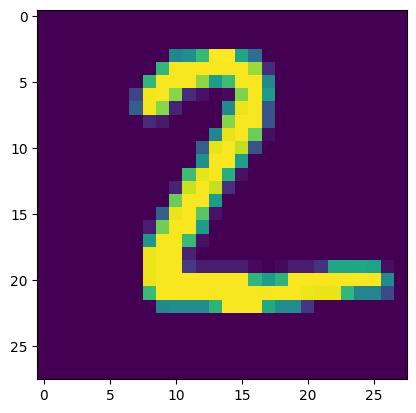

In [65]:
for i, test_row in df_test.iterrows():
    test_row.drop(0, inplace=True)
    row_np = test_row.to_numpy()
    row_np = row_np.reshape((28,28))
    plt.imshow(row_np)
    test_row = test_row.to_list()
    if i == 1:
        break

In [38]:
def findDistSqrd(point1: list[int], point2: list[int]) -> int:
    distSqrd = 0
    for j in range(len(point1)):
        distSqrd += (point1[j] - point2[j])**2
    return distSqrd

In [80]:
def calcTrainsetDist(test_row):
    """
    Calculates the distances between the given test_row and each entry in the
    training set.
    Returns a list of tuples (distance squared, correct class).
    """
    distances: list[tuple[int, int]] = []
    for _, examp_row in df_train.iterrows():
        examp_row = examp_row.to_list()
        distances.append((findDistSqrd(test_row, examp_row[1:]),
                        examp_row[0]))
    return distances

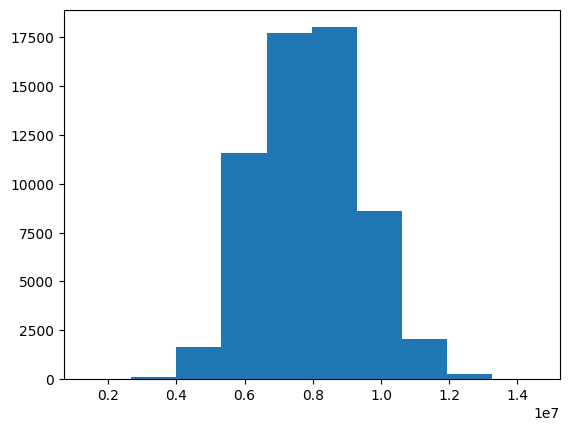

In [81]:
distances = calcTrainsetDist(test_row)
plt.hist([t[0] for t in distances])
plt.show()

In [85]:
distances.sort()

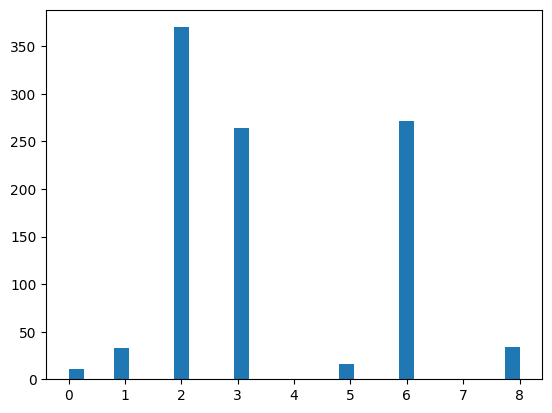

In [86]:
plt.hist([t[1] for t in distances[:1000]], bins=30)
plt.show()

In [91]:
def findPredClass(distances, k=200, num_classes=10):
    distances.sort()
    counts = [0]*num_classes
    for _, val in distances[:k]:
        counts[val] += 1
    print(counts)
    max = 0
    id = None
    for i in range(num_classes):
        if counts[i] > max:
            max = counts[i]
            id = i
    return id

In [88]:
findPredClass(distances)

2

In [94]:
five = list((plt.imread('number_knn/five.png')*255).astype(int).reshape((784,)))
findPredClass(calcTrainsetDist(five))

[6, 0, 21, 15, 0, 7, 8, 143, 0, 0]


7

In [96]:
three = list((plt.imread('number_knn/three.png')*255).astype(int).reshape((784,)))
findPredClass(calcTrainsetDist(three))

[2, 0, 2, 162, 0, 23, 7, 0, 2, 2]


3

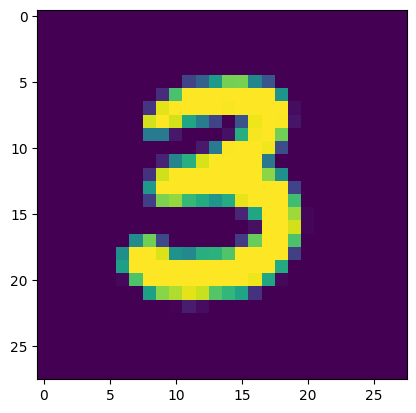

In [97]:
plt.imshow(np.array(three).reshape((28,28)))